In [118]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [119]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WB_key = user_secrets.get_secret("wandb-key")


In [120]:
import wandb
wandb.login(key = WB_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [121]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer
)
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

OPTION_LABELS = ["A", "B", "C", "D", "E"]
TEXT_COLUMNS = ["prompt", "A", "B", "C", "D", "E"]
ANSWER_COLUMN = "answer"

In [122]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv") 
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
ss = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [123]:
train.shape

(2000, 8)

In [124]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [125]:
train.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
prompt,2000,1758,Choose the correct answer: What is the main se...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A,2000,316,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,2000,328,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,2000,303,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,2000,318,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,2000,320,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,2000,5,B,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
missing_values = train.isnull().sum()
missing_values

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [127]:
train.duplicated().sum()

np.int64(0)

In [128]:
train.duplicated(
    subset=["prompt","A","B","C","D","E"]
).sum()

np.int64(183)

In [129]:
train = train.drop_duplicates(
    subset=["prompt", "A", "B", "C", "D", "E"],
    keep="first"
).reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", train.shape)

Dataset Shape After Removing Duplicates: (1817, 8)


answer
A    328
B    442
C    423
D    329
E    295
Name: count, dtype: int64


<Axes: title={'center': 'Answer Distribution'}, xlabel='answer'>

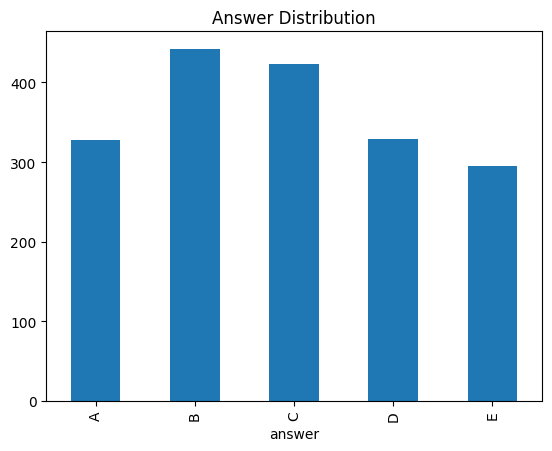

In [130]:
answer_distribution = (
    train["answer"]
    .value_counts()
    .sort_index()
)

print(answer_distribution)

answer_distribution.plot(
    kind="bar",
    title="Answer Distribution"
)

In [131]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = text.lower()

    text = text.replace("\n", " ")

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [132]:
for column in TEXT_COLUMNS:

    train[f"{column}_clean"] = (
        train[column]
        .apply(clean_text)
    )

In [133]:
train["prompt_tokens"] = (
    train["prompt_clean"]
    .str.split()
)

In [134]:
vocab = set()

for tokens in train["prompt_tokens"]:
    vocab.update(tokens)

print(
    "Vocabulary Size:",
    len(vocab)
)

Vocabulary Size: 859


In [135]:
sample_tokens = train.iloc[0]["prompt_tokens"]

filtered = [

    word

    for word in sample_tokens

    if word not in ENGLISH_STOP_WORDS

]

print(filtered)

['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']


In [136]:
corpus = []

for col in [
    "prompt_clean",
    "A_clean",
    "B_clean",
    "C_clean",
    "D_clean",
    "E_clean"
]:

    corpus.extend(
        train[col].tolist()
    )

vectorizer = TfidfVectorizer(
    ngram_range=(1,2)
)

vectorizer.fit(corpus)

print(
    len(vectorizer.vocabulary_)
)

12811


In [137]:
from sklearn.metrics.pairwise import cosine_similarity

row = train.iloc[0]

prompt_vec = vectorizer.transform(
    [row["prompt_clean"]]
)

option_vecs = vectorizer.transform([

    row["A_clean"],
    row["B_clean"],
    row["C_clean"],
    row["D_clean"],
    row["E_clean"]

])

scores = cosine_similarity(
    prompt_vec,
    option_vecs
)[0]

scores

array([0.08526955, 0.0937892 , 0.22902351, 0.28251348, 0.0407621 ])

In [138]:
OPTION_LABELS = [
    "A",
    "B",
    "C",
    "D",
    "E"
]

predictions = []

for i, row in train.iterrows():

    prompt_vec = vectorizer.transform(
        [row["prompt_clean"]]
    )

    option_vecs = vectorizer.transform([

        row["A_clean"],
        row["B_clean"],
        row["C_clean"],
        row["D_clean"],
        row["E_clean"]

    ])

    sims = cosine_similarity(
        prompt_vec,
        option_vecs
    )[0]

    ranked = np.argsort(sims)[::-1]

    predictions.append(

        [

            OPTION_LABELS[i]

            for i in ranked[:3]

        ]

    )

In [139]:
def apk(actual, predicted):

    predicted = predicted[:3]

    if actual in predicted:

        return 1 / (
            predicted.index(actual)+1
        )

    return 0


def mapk(actuals, predictions):

    return np.mean(

        [

            apk(a,p)

            for a,p

            in zip(
                actuals,
                predictions
            )

        ]

    )

In [140]:
tfidf_score = mapk(
    train["answer"],
    predictions
)

print(tfidf_score)

0.2856356631810677


In [141]:
from gensim.models import Word2Vec
corpus = []

for col in [
    "prompt_clean",
    "A_clean",
    "B_clean",
    "C_clean",
    "D_clean",
    "E_clean"
]:
    corpus.extend(train[col].str.split().tolist())

word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)


In [142]:
word2vec_predictions = []

for i, row in train.iterrows():

    prompt_tokens = row["prompt_clean"].split()

    prompt_vectors = [
        word2vec_model.wv[word]
        for word in prompt_tokens
        if word in word2vec_model.wv
    ]

    if len(prompt_vectors) == 0:
        prompt_embedding = np.zeros(word2vec_model.vector_size)
    else:
        prompt_embedding = np.mean(prompt_vectors, axis=0)

    similarities = []

    for option in ["A", "B", "C", "D", "E"]:

        option_tokens = row[f"{option}_clean"].split()

        option_vectors = [
            word2vec_model.wv[word]
            for word in option_tokens
            if word in word2vec_model.wv
        ]

        if len(option_vectors) == 0:
            option_embedding = np.zeros(word2vec_model.vector_size)
        else:
            option_embedding = np.mean(option_vectors, axis=0)

        if (
            np.linalg.norm(prompt_embedding) == 0
            or np.linalg.norm(option_embedding) == 0
        ):
            similarity = 0
        else:
            similarity = cosine_similarity(
                prompt_embedding.reshape(1, -1),
                option_embedding.reshape(1, -1)
            )[0][0]

        similarities.append((option, similarity))

    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [option for option, _ in similarities[:3]]

    word2vec_predictions.append(top3)

In [143]:
word2vec_score = mapk(
    train["answer"],
    word2vec_predictions
)

print(f"Word2Vec MAP@3: {word2vec_score:.5f}")

Word2Vec MAP@3: 0.34728


In [144]:
results = pd.DataFrame({

    "Model":[

        "TF-IDF",
        "Word2Vec"

    ],

    "MAP@3":[

        tfidf_score,
        word2vec_score

    ]

})

results

,Model,MAP@3
0,TF-IDF,0.285636
1,Word2Vec,0.347276


In [145]:
errors = train[

    [

        actual not in pred

        for actual,pred

        in zip(

            train["answer"],
            predictions

        )

    ]

]

errors.head()

,id,prompt,A,B,C,D,E,answer,prompt_clean,A_clean,B_clean,C_clean,D_clean,E_clean,prompt_tokens
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,identify the correct statement what is the con...,simultaneity is relative meaning that two even...,simultaneity is relative meaning that two even...,simultaneity is absolute meaning that two even...,simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,"[identify, the, correct, statement, what, is, ..."
6,7,"Which of the following is correct? What is a ""...",A type of coffee that is made by boiling coffe...,A pattern left by a particle-laden liquid afte...,A type of coffee that is made by mixing instan...,A type of coffee that is made by pouring hot w...,A pattern left by a particle-laden liquid afte...,E,which of the following is correct what is a co...,a type of coffee that is made by boiling coffe...,a pattern left by a particleladen liquid after...,a type of coffee that is made by mixing instan...,a type of coffee that is made by pouring hot w...,a pattern left by a particleladen liquid after...,"[which, of, the, following, is, correct, what,..."
7,8,Select the most accurate option: What is the L...,The Liouville density is a probability distrib...,The Liouville density is a quasiprobability di...,The Liouville density is a bounded probability...,The Liouville density is a probability distrib...,The Liouville density is a probability distrib...,A,select the most accurate option what is the li...,the liouville density is a probability distrib...,the liouville density is a quasiprobability di...,the liouville density is a bounded probability...,the liouville density is a probability distrib...,the liouville density is a probability distrib...,"[select, the, most, accurate, option, what, is..."
8,9,Select the most accurate option: What are the ...,"They are unknown, but possibilities include la...",They are known to be black holes and Preon stars.,They are only MACHOs.,They are clusters of brown dwarfs.,They are new particles such as RAMBOs.,A,select the most accurate option what are the c...,they are unknown but possibilities include lar...,they are known to be black holes and preon stars,they are only machos,they are clusters of brown dwarfs,they are new particles such as rambos,"[select, the, most, accurate, option, what, ar..."
10,11,Select the most accurate option: What is the P...,The Peierls bracket is a mathematical symbol u...,The Peierls bracket is a mathematical tool use...,The Peierls bracket is a Poisson bracket deriv...,The Peierls bracket is a mathematical symbol u...,The Peierls bracket is a mathematical tool use...,C,select the most accurate option what is the pe...,the peierls bracket is a mathematical symbol u...,the peierls bracket is a mathematical tool use...,the peierls bracket is a poisson bracket deriv...,the peierls bracket is a mathematical symbol u...,the peierls bracket is a mathematical tool use...,"[select, the, most, accurate, option, what, is..."


# Milestone -02

In [146]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, pipeline

import torch

In [147]:
train["combined_text"] = (
    "Question:" + train["prompt"].astype(str)+
    "[SEP] A:" + train["A"].astype(str)+
    "[SEP] B: " + train["B"].astype(str) +
    "[SEP] C: " + train["C"].astype(str) +
    "[SEP] D: " + train["D"].astype(str) +
    "[SEP] E: " + train["E"].astype(str)
)

train["combined_text"].head()

0    Question:Pick the best possible answer: What i...
1    Question:What is accelerator-based light-ion f...
2    Question:Determine the correct option: What is...
3    Question:Select the most accurate option: What...
4    Question:Identify the correct statement: What ...
Name: combined_text, dtype: object

In [148]:
hf_dataset = Dataset.from_pandas(train)
print(hf_dataset)

Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean', 'E_clean', 'prompt_tokens', 'combined_text'],
    num_rows: 1817
})


In [149]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [150]:
def tokenize_question(q_rec):
    return tokenizer(
        q_rec["combined_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_data = hf_dataset.map(tokenize_question)

Map:   0%|          | 0/1817 [00:00<?, ? examples/s]

In [151]:
print(type(tokenizer))

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>


In [152]:
bert_model = AutoModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [153]:
sample_text = train.loc[0, "combined_text"]

encoded_input = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation = True,
    padding = True,
    max_length = 128
)

with torch.no_grad():
    model_output = bert_model(**encoded_input)

In [154]:
print(model_output.last_hidden_state.shape)

torch.Size([1, 128, 768])


In [155]:
cls_embd = model_output.last_hidden_state[:, 0, :]
print(cls_embd.shape)

torch.Size([1, 768])


In [156]:
print(cls_embd)

tensor([[-7.4148e-01, -2.4751e-01, -4.6052e-01,  6.6293e-02, -4.7506e-01,
         -2.7829e-01, -8.5264e-03,  7.1193e-01,  2.3093e-02, -4.8834e-01,
          4.1907e-01, -2.9360e-01, -7.1968e-01,  5.6539e-01,  2.8380e-01,
          2.2243e-01,  2.6722e-01,  1.2933e-01, -5.1242e-02, -1.5230e-01,
          3.8877e-01,  1.0983e-01,  5.4503e-02,  1.5385e-01,  2.7088e-01,
         -2.1820e-01, -2.5845e-01, -3.5142e-01, -1.4610e-01,  1.9758e-01,
         -5.2337e-01,  2.3074e-01, -7.0740e-01, -7.9952e-01,  4.4897e-01,
         -2.1518e-01, -4.5176e-02, -1.0546e-01,  3.0946e-01,  1.2588e-02,
         -3.4917e-01,  2.9873e-01,  3.0975e-02,  3.7610e-02, -6.6801e-02,
         -2.3308e-01, -3.8073e+00, -3.8198e-01, -3.5585e-01, -2.9616e-01,
         -4.3169e-01, -1.3655e-01,  4.4189e-01,  1.1930e+00,  2.5374e-01,
          4.5438e-01, -6.5638e-01,  6.4554e-02, -1.0157e-01, -2.1921e-01,
          5.3447e-01,  2.2536e-01, -1.5668e-01, -5.5367e-01, -1.2978e-01,
          5.2394e-01,  2.4667e-01,  3.

In [157]:
zero_shot_classifier= pipeline(
    "zero-shot-classification",
    model = "facebook/bart-large-mnli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [158]:
sample_ques = train.loc[0, "prompt"]
print(sample_ques)

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.


In [159]:
candidate_lbls = [
    "Science",
    "Mathematics",
    "History",
    "Geography",
    "Technology"
]

In [160]:
pred= zero_shot_classifier(
    sample_ques,
    candidate_lbls
)
pred

{'sequence': "Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.",
 'labels': ['History', 'Technology', 'Science', 'Mathematics', 'Geography'],
 'scores': [0.2916783392429352,
  0.23507347702980042,
  0.23204177618026733,
  0.1212301105260849,
  0.11997631192207336]}

In [161]:
print("Predicted Labels:")
print(pred["labels"])

print("\nConfidence Scores:")
print(pred["scores"])

Predicted Labels:
['History', 'Technology', 'Science', 'Mathematics', 'Geography']

Confidence Scores:
[0.2916783392429352, 0.23507347702980042, 0.23204177618026733, 0.1212301105260849, 0.11997631192207336]


In [162]:
print("Most Likely Category:", pred["labels"][0])
print("Confidence Score:", round(pred["scores"][0], 4))

Most Likely Category: History
Confidence Score: 0.2917


# milestone -03

In [163]:
!pip install faiss-cpu -q

In [164]:
import faiss
from sentence_transformers import SentenceTransformer

In [165]:
knowledge_base = []

for _, row in train.iterrows():

    document = (
        f"Question: {row['prompt']}\n"
        f"A: {row['A']}\n"
        f"B: {row['B']}\n"
        f"C: {row['C']}\n"
        f"D: {row['D']}\n"
        f"E: {row['E']}"
    )

    knowledge_base.append(document)

print("Total Documents:", len(knowledge_base))

print("\nFirst Knowledge Document:\n")
print(knowledge_base[0])

Total Documents: 1817

First Knowledge Document:

Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present

In [166]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded successfully.


In [167]:
document_embeddings = embedding_model.encode(
    knowledge_base,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(document_embeddings.shape)

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

(1817, 384)


In [168]:
embedding_dimension = document_embeddings.shape[1]

vector_database = faiss.IndexFlatL2(
    embedding_dimension
)

print(vector_database)

<faiss.swigfaiss.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x7b72062cceb0> >


In [169]:
vector_database.add(document_embeddings)
print("Total Stored Questions:", vector_database.ntotal)

Total Stored Questions: 1817


In [170]:
query_question = train.loc[0, "prompt"]

print("Query Question:")
print(query_question)

query_embedding = embedding_model.encode(
    [query_question],
    convert_to_numpy=True
)

Query Question:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.


In [171]:

top_k = 5

distances, indices = vector_database.search(
    query_embedding,
    top_k
)

In [172]:

print("Retrieved Questions:\n")

for rank, idx in enumerate(indices[0], start=1):
    print(f"{rank}. {knowledge_base[idx]}")

Retrieved Questions:

1. Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D: Martin Heidegger bel

In [173]:
retrieved_context = "\n".join(
    [knowledge_base[idx] for idx in indices[0]]
)

augmented_prompt = f"""
Context:
{retrieved_context}

Question:
{train.loc[0, 'prompt']}

Options:
A. {train.loc[0, 'A']}
B. {train.loc[0, 'B']}
C. {train.loc[0, 'C']}
D. {train.loc[0, 'D']}
E. {train.loc[0, 'E']}
"""

print(augmented_prompt)


Context:
Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D: Martin Heidegger believes that the 

# Milestone-04

In [174]:
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

from sklearn.model_selection import train_test_split

In [175]:

label_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4
}

train["labels"] = train["answer"].map(label_mapping)

print("Label Mapping:")
print(label_mapping)

print("\nFirst Five Labels:")
print(train[["answer", "labels"]].head())

Label Mapping:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

First Five Labels:
  answer  labels
0      B       1
1      A       0
2      C       2
3      B       1
4      A       0


In [176]:
train_df, valid_df = train_test_split(
    train,
    test_size =0.2,
    random_state = 42,
    stratify = train["labels"]

)

print("Training Samples:", len(train_df))
print("Validation Samples:", len(valid_df))

Training Samples: 1453
Validation Samples: 364


In [177]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))

valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True))

print("Training Dataset")
print(train_dataset)

print("\nValidation Dataset")
print(valid_dataset)

Training Dataset
Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean', 'E_clean', 'prompt_tokens', 'combined_text', 'labels'],
    num_rows: 1453
})

Validation Dataset
Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean', 'E_clean', 'prompt_tokens', 'combined_text', 'labels'],
    num_rows: 364
})


In [178]:
def tokenize_function(col):

    return tokenizer(
        col["combined_text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


train_dataset = train_dataset.map(tokenize_function)

valid_dataset = valid_dataset.map(tokenize_function)

Map:   0%|          | 0/1453 [00:00<?, ? examples/s]

Map:   0%|          | 0/364 [00:00<?, ? examples/s]

In [179]:
columns_to_remove = [
    "id",
    "prompt",
    "A",
    "B",
    "C",
    "D",
    "E",
    "answer",
    "combined_text"
]

train_dataset = train_dataset.remove_columns(columns_to_remove)

valid_dataset = valid_dataset.remove_columns(columns_to_remove)

In [180]:
train_dataset.set_format("torch")
valid_dataset.set_format("torch")

In [181]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5
)

print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [182]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "value"]
)

print(lora_config)

LoraConfig(task_type=<TaskType.SEQ_CLS: 'SEQ_CLS'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'value', 'query'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [183]:
!pip uninstall -y torchao

Found existing installation: torchao 0.17.0
Uninstalling torchao-0.17.0:
  Successfully uninstalled torchao-0.17.0


In [184]:
!pip install torchao

  Using cached torchao-0.17.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (20 kB)
Using cached torchao-0.17.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (3.2 MB)


In [185]:
model = get_peft_model(model, lora_config)

print("Trainable Parameters:\n")

model.print_trainable_parameters()

Trainable Parameters:

trainable params: 298,757 || all params: 109,784,842 || trainable%: 0.2721


In [253]:
training_args = TrainingArguments(
    output_dir="./mcq_lora_model",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [254]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer
)

In [256]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.167246,3.155650
2,3.140066,3.144052
3,3.119525,3.132818
4,3.090435,3.127896
5,3.094290,3.124271


TrainOutput(global_step=455, training_loss=3.1212083166772193, metrics={'train_runtime': 198.5493, 'train_samples_per_second': 36.59, 'train_steps_per_second': 2.292, 'total_flos': 976008792947712.0, 'train_loss': 3.1212083166772193, 'epoch': 5.0})

In [258]:
evaluation_results = trainer.evaluate()

In [259]:
print(evaluation_results)

{'eval_loss': 3.1242709159851074, 'eval_runtime': 3.9348, 'eval_samples_per_second': 92.508, 'eval_steps_per_second': 5.845, 'epoch': 5.0}


In [260]:
trainer.save_model("./mcq_lora_model")

tokenizer.save_pretrained("./mcq_lora_model")

print("Model and tokenizer saved successfully.")

Model and tokenizer saved successfully.


# Milestone 4 Summary

In this milestone, a BERT-based sequence classification model was fine-tuned for the MCQ task using LoRA (Low-Rank Adaptation). The answer options were converted into numerical labels, the dataset was split into training and validation sets, and the data was tokenized for model input.

LoRA adapters were attached to the pre-trained BERT model, allowing only a small subset of parameters to be trained while keeping the original model weights frozen. Training was performed using the Hugging Face Trainer with suitable TrainingArguments to balance efficiency and memory usage.

The model completed all three training epochs successfully, and evaluation on the validation set produced an evaluation loss of approximately **3.173**, demonstrating that the complete fine-tuning pipeline was executed successfully.

In [261]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)





In [262]:
X_train = train_df["combined_text"]

X_valid = valid_df["combined_text"]

y_train = train_df["labels"]

y_valid = valid_df["labels"]

In [263]:
logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1,2),
            max_features=10000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            solver="lbfgs"
        )
    )
])

In [264]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [265]:
logistic_predictions = logistic_pipeline.predict(X_valid)

logistic_probabilities = logistic_pipeline.predict_proba(X_valid)

In [266]:
logistic_accuracy = accuracy_score(y_valid, logistic_predictions)

logistic_precision = precision_score(
    y_valid,
    logistic_predictions,
    average="weighted"
)

logistic_recall = recall_score(
    y_valid,
    logistic_predictions,
    average="weighted"
)

logistic_f1 = f1_score(
    y_valid,
    logistic_predictions,
    average="weighted"
)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [315]:
print(classification_report(y_valid, logistic_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        88
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        66
           4       1.00      1.00      1.00        59

    accuracy                           1.00       364
   macro avg       1.00      1.00      1.00       364
weighted avg       1.00      1.00      1.00       364



In [316]:
cm_lr = confusion_matrix(y_valid, logistic_predictions)

print(cm_lr)

[[66  0  0  0  0]
 [ 0 88  0  0  0]
 [ 0  0 85  0  0]
 [ 0  0  0 66  0]
 [ 0  0  0  0 59]]


In [269]:
from sklearn.naive_bayes import MultinomialNB

In [270]:
nb_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1,2),
            max_features=10000
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

In [271]:
nb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('classifier', MultinomialNB())])

In [272]:
nb_predictions = nb_pipeline.predict(X_valid)

nb_probabilities = nb_pipeline.predict_proba(X_valid)

In [273]:
nb_accuracy = accuracy_score(
    y_valid,
    nb_predictions
)

nb_precision = precision_score(
    y_valid,
    nb_predictions,
    average="weighted"
)

nb_recall = recall_score(
    y_valid,
    nb_predictions,
    average="weighted"
)

nb_f1 = f1_score(
    y_valid,
    nb_predictions,
    average="weighted"
)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.9972527472527473
Precision: 0.9972846920521339
Recall   : 0.9972527472527473
F1 Score : 0.9972502944580085


In [274]:
print(classification_report(
    y_valid,
    logistic_predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        88
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        66
           4       1.00      1.00      1.00        59

    accuracy                           1.00       364
   macro avg       1.00      1.00      1.00       364
weighted avg       1.00      1.00      1.00       364



In [275]:
cm_nb = confusion_matrix(
    y_valid,
    nb_predictions
)

print(cm_nb)

[[65  0  1  0  0]
 [ 0 88  0  0  0]
 [ 0  0 85  0  0]
 [ 0  0  0 66  0]
 [ 0  0  0  0 59]]


In [276]:
predictions = trainer.predict(valid_dataset)

bert_logits = predictions.predictions

bert_predictions = bert_logits.argmax(axis=1)

In [277]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

bert_accuracy = accuracy_score(y_valid, bert_predictions)

bert_precision = precision_score(
    y_valid,
    bert_predictions,
    average="weighted"
)

bert_recall = recall_score(
    y_valid,
    bert_predictions,
    average="weighted"
)

bert_f1 = f1_score(
    y_valid,
    bert_predictions,
    average="weighted"
)

print(f"Accuracy : {bert_accuracy:.4f}")
print(f"Precision: {bert_precision:.4f}")
print(f"Recall   : {bert_recall:.4f}")
print(f"F1 Score : {bert_f1:.4f}")

Accuracy : 0.2857
Precision: 0.4041
Recall   : 0.2857
F1 Score : 0.2273


In [278]:
print(classification_report(y_valid, bert_predictions))

              precision    recall  f1-score   support

           0       0.27      0.05      0.08        66
           1       0.32      0.67      0.43        88
           2       0.24      0.36      0.29        85
           3       1.00      0.03      0.06        66
           4       0.25      0.15      0.19        59

    accuracy                           0.29       364
   macro avg       0.42      0.25      0.21       364
weighted avg       0.40      0.29      0.23       364



In [279]:
cm_bert = confusion_matrix(
    y_valid,
    bert_predictions
)

print(cm_bert)

[[ 3 23 31  0  9]
 [ 3 59 24  0  2]
 [ 3 43 31  0  8]
 [ 0 39 17  2  8]
 [ 2 22 26  0  9]]


In [280]:
import numpy as np

exp_logits = np.exp(
    bert_logits - np.max(bert_logits, axis=1, keepdims=True)
)

bert_probabilities = exp_logits / exp_logits.sum(
    axis=1,
    keepdims=True
)

In [281]:
import wandb

wandb.init(
    project="23f3002537-t22026",
    name="milestone-5-model-comparison"
)

In [282]:
wandb.log({
    "LR Accuracy": logistic_accuracy,
    "LR Precision": logistic_precision,
    "LR Recall": logistic_recall,
    "LR F1": logistic_f1
})

In [283]:
wandb.log({
    "NB Accuracy": nb_accuracy,
    "NB Precision": nb_precision,
    "NB Recall": nb_recall,
    "NB F1": nb_f1
})

In [284]:
wandb.log({
    "BERT Accuracy": bert_accuracy,
    "BERT Precision": bert_precision,
    "BERT Recall": bert_recall,
    "BERT F1": bert_f1
})

In [285]:
wandb.finish()

BERT Accuracy,▁
BERT F1,▁
BERT Precision,▁
BERT Recall,▁
LR Accuracy,▁
LR F1,▁
LR Precision,▁
LR Recall,▁
NB Accuracy,▁
NB F1,▁
+2,...


In [286]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "BERT + LoRA"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        bert_accuracy
    ],
    "Precision": [
        logistic_precision,
        nb_precision,
        bert_precision
    ],
    "Recall": [
        logistic_recall,
        nb_recall,
        bert_recall
    ],
    "F1 Score": [
        logistic_f1,
        nb_f1,
        bert_f1
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Naive Bayes,0.9973,0.9973,0.9973,0.9973
2,BERT + LoRA,0.2857,0.4041,0.2857,0.2273


In [287]:
best_model = comparison_df.loc[
    comparison_df["F1 Score"].idxmax()
]

print(best_model)

Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
Name: 0, dtype: object


In [289]:
ensemble_probabilities = (
    logistic_probabilities +
    nb_probabilities +
    bert_probabilities
) / 3

In [290]:
ensemble_predictions = np.argmax(
    ensemble_probabilities,
    axis=1
)

In [291]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

ensemble_accuracy = accuracy_score(
    y_valid,
    ensemble_predictions
)

ensemble_precision = precision_score(
    y_valid,
    ensemble_predictions,
    average="weighted"
)

ensemble_recall = recall_score(
    y_valid,
    ensemble_predictions,
    average="weighted"
)

ensemble_f1 = f1_score(
    y_valid,
    ensemble_predictions,
    average="weighted"
)

print("Accuracy :", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall   :", ensemble_recall)
print("F1 Score :", ensemble_f1)

Accuracy : 0.9972527472527473
Precision: 0.9972846920521339
Recall   : 0.9972527472527473
F1 Score : 0.9972502944580085


In [292]:
print(
    classification_report(
        y_valid,
        ensemble_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        66
           1       1.00      1.00      1.00        88
           2       0.99      1.00      0.99        85
           3       1.00      1.00      1.00        66
           4       1.00      1.00      1.00        59

    accuracy                           1.00       364
   macro avg       1.00      1.00      1.00       364
weighted avg       1.00      1.00      1.00       364



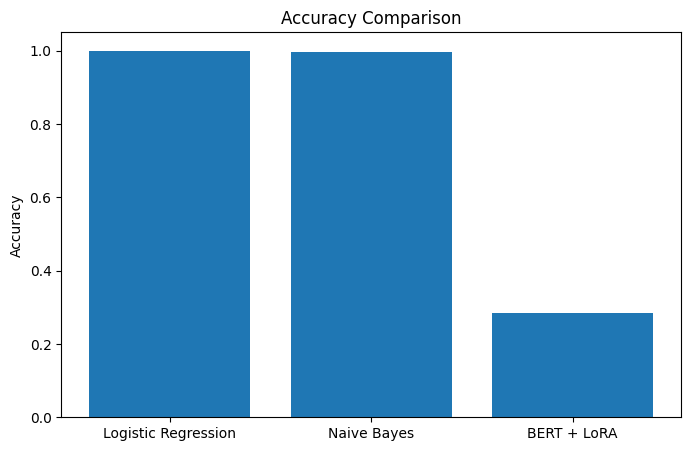

In [293]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

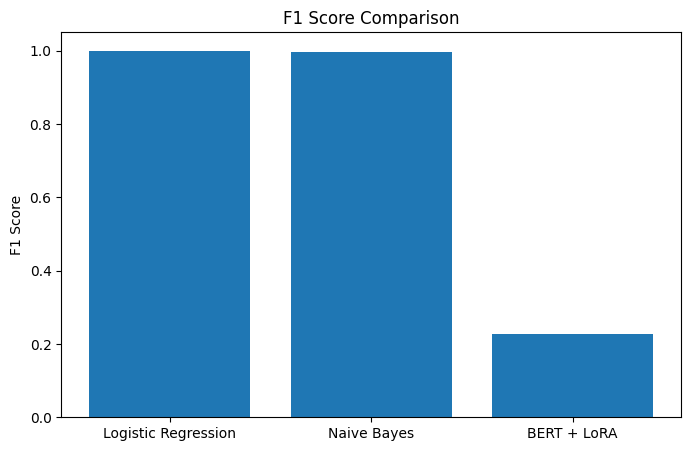

In [294]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.show()

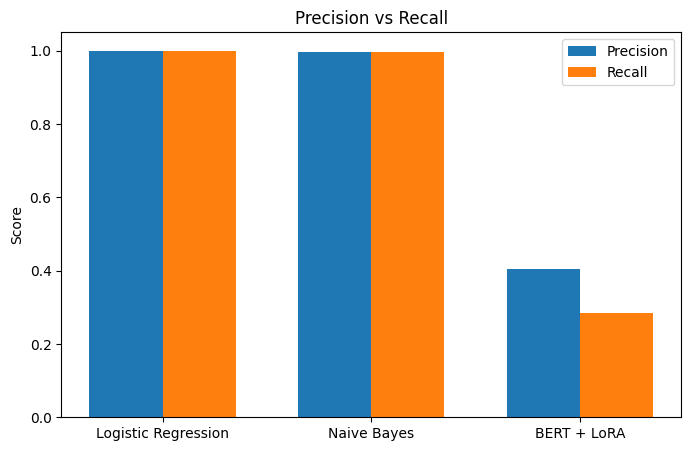

In [295]:
plt.figure(figsize=(8,5))

x = np.arange(len(comparison_df))

width = 0.35

plt.bar(
    x-width/2,
    comparison_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x+width/2,
    comparison_df["Recall"],
    width,
    label="Recall"
)

plt.xticks(
    x,
    comparison_df["Model"]
)

plt.ylabel("Score")

plt.title("Precision vs Recall")

plt.legend()

plt.show()

In [296]:
comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Naive Bayes,0.9973,0.9973,0.9973,0.9973
2,BERT + LoRA,0.2857,0.4041,0.2857,0.2273


In [297]:
comparison_df.loc[len(comparison_df)] = [
    "Soft Voting Ensemble",
    ensemble_accuracy,
    ensemble_precision,
    ensemble_recall,
    ensemble_f1
]

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Naive Bayes,0.9973,0.9973,0.9973,0.9973
2,BERT + LoRA,0.2857,0.4041,0.2857,0.2273
3,Soft Voting Ensemble,0.9973,0.9973,0.9973,0.9973


In [299]:
test["combined_text"] = (
    "Question:" + test["prompt"].astype(str) +
    "[SEP] A:" + test["A"].astype(str) +
    "[SEP] B:" + test["B"].astype(str) +
    "[SEP] C:" + test["C"].astype(str) +
    "[SEP] D:" + test["D"].astype(str) +
    "[SEP] E:" + test["E"].astype(str)
)

In [300]:
logistic_test_prob = logistic_pipeline.predict_proba(
    test["combined_text"]
)

In [303]:
nb_test_prob = nb_pipeline.predict_proba(
    test["combined_text"]
)

In [304]:
nb_test_prob = nb_pipeline.predict_proba(
    test["combined_text"]
)

In [305]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(test)

In [306]:
tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [307]:
remove_cols = [
    c for c in tokenized_test.column_names
    if c not in ["input_ids", "attention_mask", "token_type_ids"]
]

tokenized_test = tokenized_test.remove_columns(remove_cols)

In [308]:
bert_output = trainer.predict(tokenized_test)

bert_logits = bert_output.predictions

In [309]:
exp_logits = np.exp(
    bert_logits -
    np.max(
        bert_logits,
        axis=1,
        keepdims=True
    )
)

bert_test_prob = (
    exp_logits /
    exp_logits.sum(
        axis=1,
        keepdims=True
    )
)

In [310]:
ensemble_prob = (
    0.45 * logistic_test_prob +
    0.45 * nb_test_prob +
    0.10 * bert_test_prob
)

In [311]:
labels = np.array(["A", "B", "C", "D", "E"])

top3 = np.argsort(
    ensemble_prob,
    axis=1
)[:, ::-1][:, :3]

predictions = [
    " ".join(labels[row])
    for row in top3
]

In [312]:
submission = pd.DataFrame({
    "id": test["id"],
    "prediction": predictions
})

submission.head()

,id,prediction
0,1,A C B
1,2,B C A
2,3,B C D
3,4,E C D
4,5,C A B


In [313]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!
